In [3]:
import numpy as np

VECTORS_PATH = "/projects/ABySS_research/grant_prep/R21_single-cell-methylation/feature_vector_clustering/out/2/vectors.npy"
LABELS_PATH = "/projects/ABySS_research/grant_prep/R21_single-cell-methylation/feature_vector_clustering/out/2/labels.txt"

vectors = np.load(VECTORS_PATH)
with open(LABELS_PATH) as f:
    labels = f.read().split()
labels = list(map(lambda x: dict(zip(set(labels), range(len(labels))))[x], labels))
print(vectors.shape)

(40, 30000000)


# Cosine Distances

$d = 1 - \frac{a . b}{|a||b|}$

$a_i$ or $b_i$ == 0 $\implies$ not enough information

$a_i == b_i \implies $ same methylation status

$a_i \neq b_i \implies $ different methylation status

/projects/btl_scratch/pkazemi/miniforge/envs/main/lib/python3.10/site-packages/matplotlib/colors.py:732: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


<Axes: >

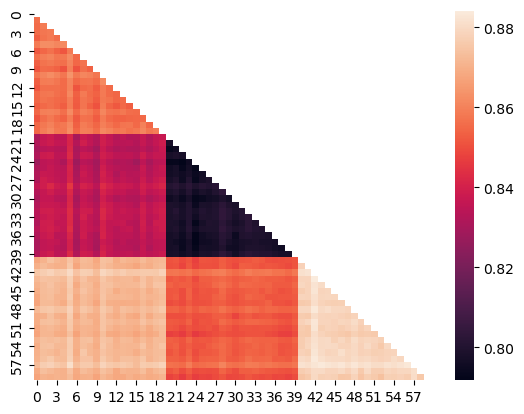

In [2]:
import seaborn as sns

num_samples = vectors.shape[0]

distances = np.empty(shape=(num_samples, num_samples))

for i in range(num_samples):
    for j in range(i):   
        n_a = np.linalg.norm(vectors[i]) + 1e-9
        n_b = np.linalg.norm(vectors[j]) + 1e-9
        distances[i][j] = 1 - np.dot(vectors[i], vectors[j]) / (n_a * n_b)

mask = np.zeros_like(distances, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(distances, mask=mask)

# Jaccard Distances

<Axes: >

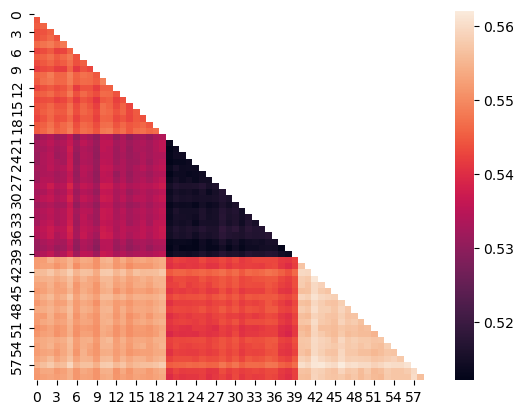

In [28]:
import seaborn as sns
import scipy.spatial.distance

num_samples = vectors.shape[0]

distances = np.zeros(shape=(num_samples, num_samples))

for i in range(num_samples):
    for j in range(i):
        distances[i][j] = scipy.spatial.distance.jaccard(vectors[i], vectors[j])

mask = np.zeros_like(distances, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(distances, mask=mask)

# Cosine Distances in 40-D Space

<Axes: >

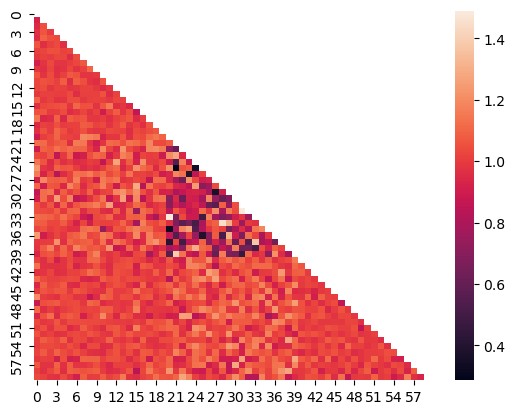

In [29]:
import seaborn as sns
import sklearn.decomposition

pca = sklearn.decomposition.PCA(n_components=40)
z = pca.fit_transform(vectors)

num_samples = z.shape[0]

distances = np.empty(shape=(num_samples, num_samples))

for i in range(num_samples):
    for j in range(i):
        n_a = np.linalg.norm(z[i]) + 1e-9
        n_b = np.linalg.norm(z[j]) + 1e-9
        distances[i][j] = 1 - np.dot(z[i], z[j]) / (n_a * n_b)

mask = np.zeros_like(distances, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(distances, mask=mask)

# Shuffle Data

In [6]:
import sklearn.utils

X, y_true = sklearn.utils.shuffle(vectors, labels)

# Hierarchal Clustering (n_clusters known)

In [9]:
import sklearn.cluster

model = sklearn.cluster.AgglomerativeClustering(3)
clusters = model.fit_predict(X)

print(clusters)
print(y_true)

[0 1 2 1 2 0 0 0 2 1 2 0 2 1 1 1 1 2 0 0 2 2 2 1 2 0 1 0 0 2 1 0 1 2 1 1 0
 1 2 0 1 0 1 1 2 1 2 2 1 0 0 0 1 2 2 2 2 0 0 0]
[0, 1, 2, 1, 2, 0, 0, 0, 2, 1, 2, 0, 2, 1, 1, 1, 1, 2, 0, 0, 2, 2, 2, 1, 2, 0, 1, 0, 0, 2, 1, 0, 1, 2, 1, 1, 0, 1, 2, 0, 1, 0, 1, 1, 2, 1, 2, 2, 1, 0, 0, 0, 1, 2, 2, 2, 2, 0, 0, 0]


In [10]:
import sklearn.metrics

print(sklearn.metrics.adjusted_rand_score(y_true, clusters))
print(sklearn.metrics.adjusted_mutual_info_score(y_true, clusters))

1.0
1.0


In [11]:
import sklearn.decomposition

pca = sklearn.decomposition.PCA(n_components=2)
z2d = pca.fit_transform(X)

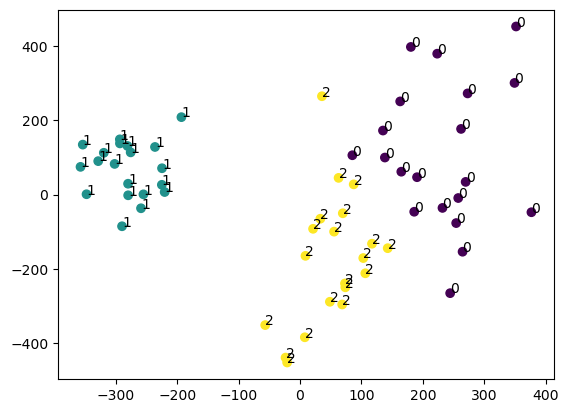

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(z2d[:, 0], z2d[:, 1], c=clusters)

for i, txt in enumerate(y_true):
    ax.annotate(txt, (z2d[i, 0], z2d[i, 1]))

# KMeans Clustering in 2D space

In [21]:
import sklearn.cluster

k_means = sklearn.cluster.KMeans(2)
clusters_2d = k_means.fit_predict(z2d)

print(clusters_2d)
print(y_true)

[0 0 0 0 0 1 1 0 1 1 1 1 0 0 1 1 0 1 0 0 1 1 1 0 0 1 1 0 0 1 0 1 0 0 1 1 0
 1 0 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [23]:
import sklearn.metrics

print(sklearn.metrics.adjusted_rand_score(y_true, clusters_2d))
print(sklearn.metrics.adjusted_mutual_info_score(y_true, clusters_2d))

0.47657894736842105
0.3785116453292704


# Hierarchal Clustering (n_clusters unknown)

In [20]:
import sklearn.cluster

model = sklearn.cluster.AgglomerativeClustering(distance_threshold=0, n_clusters=None)
clusters = model.fit_predict(X)

print(clusters)
print(y_true)

[29 21 35 23 31 30 37 27 28 26 39 36 25 38 13 33 17 32 15 19 22 24 20 10
 14 12 11 18 34 16  6  8  9  4  5  2  7  3  1  0]
[0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1]


# Hierarchal Clustering (n_clusters unknown)

In [8]:
from scipy.cluster.hierarchy import linkage

linkage_data = linkage(vectors, method="ward", metric="euclidean")

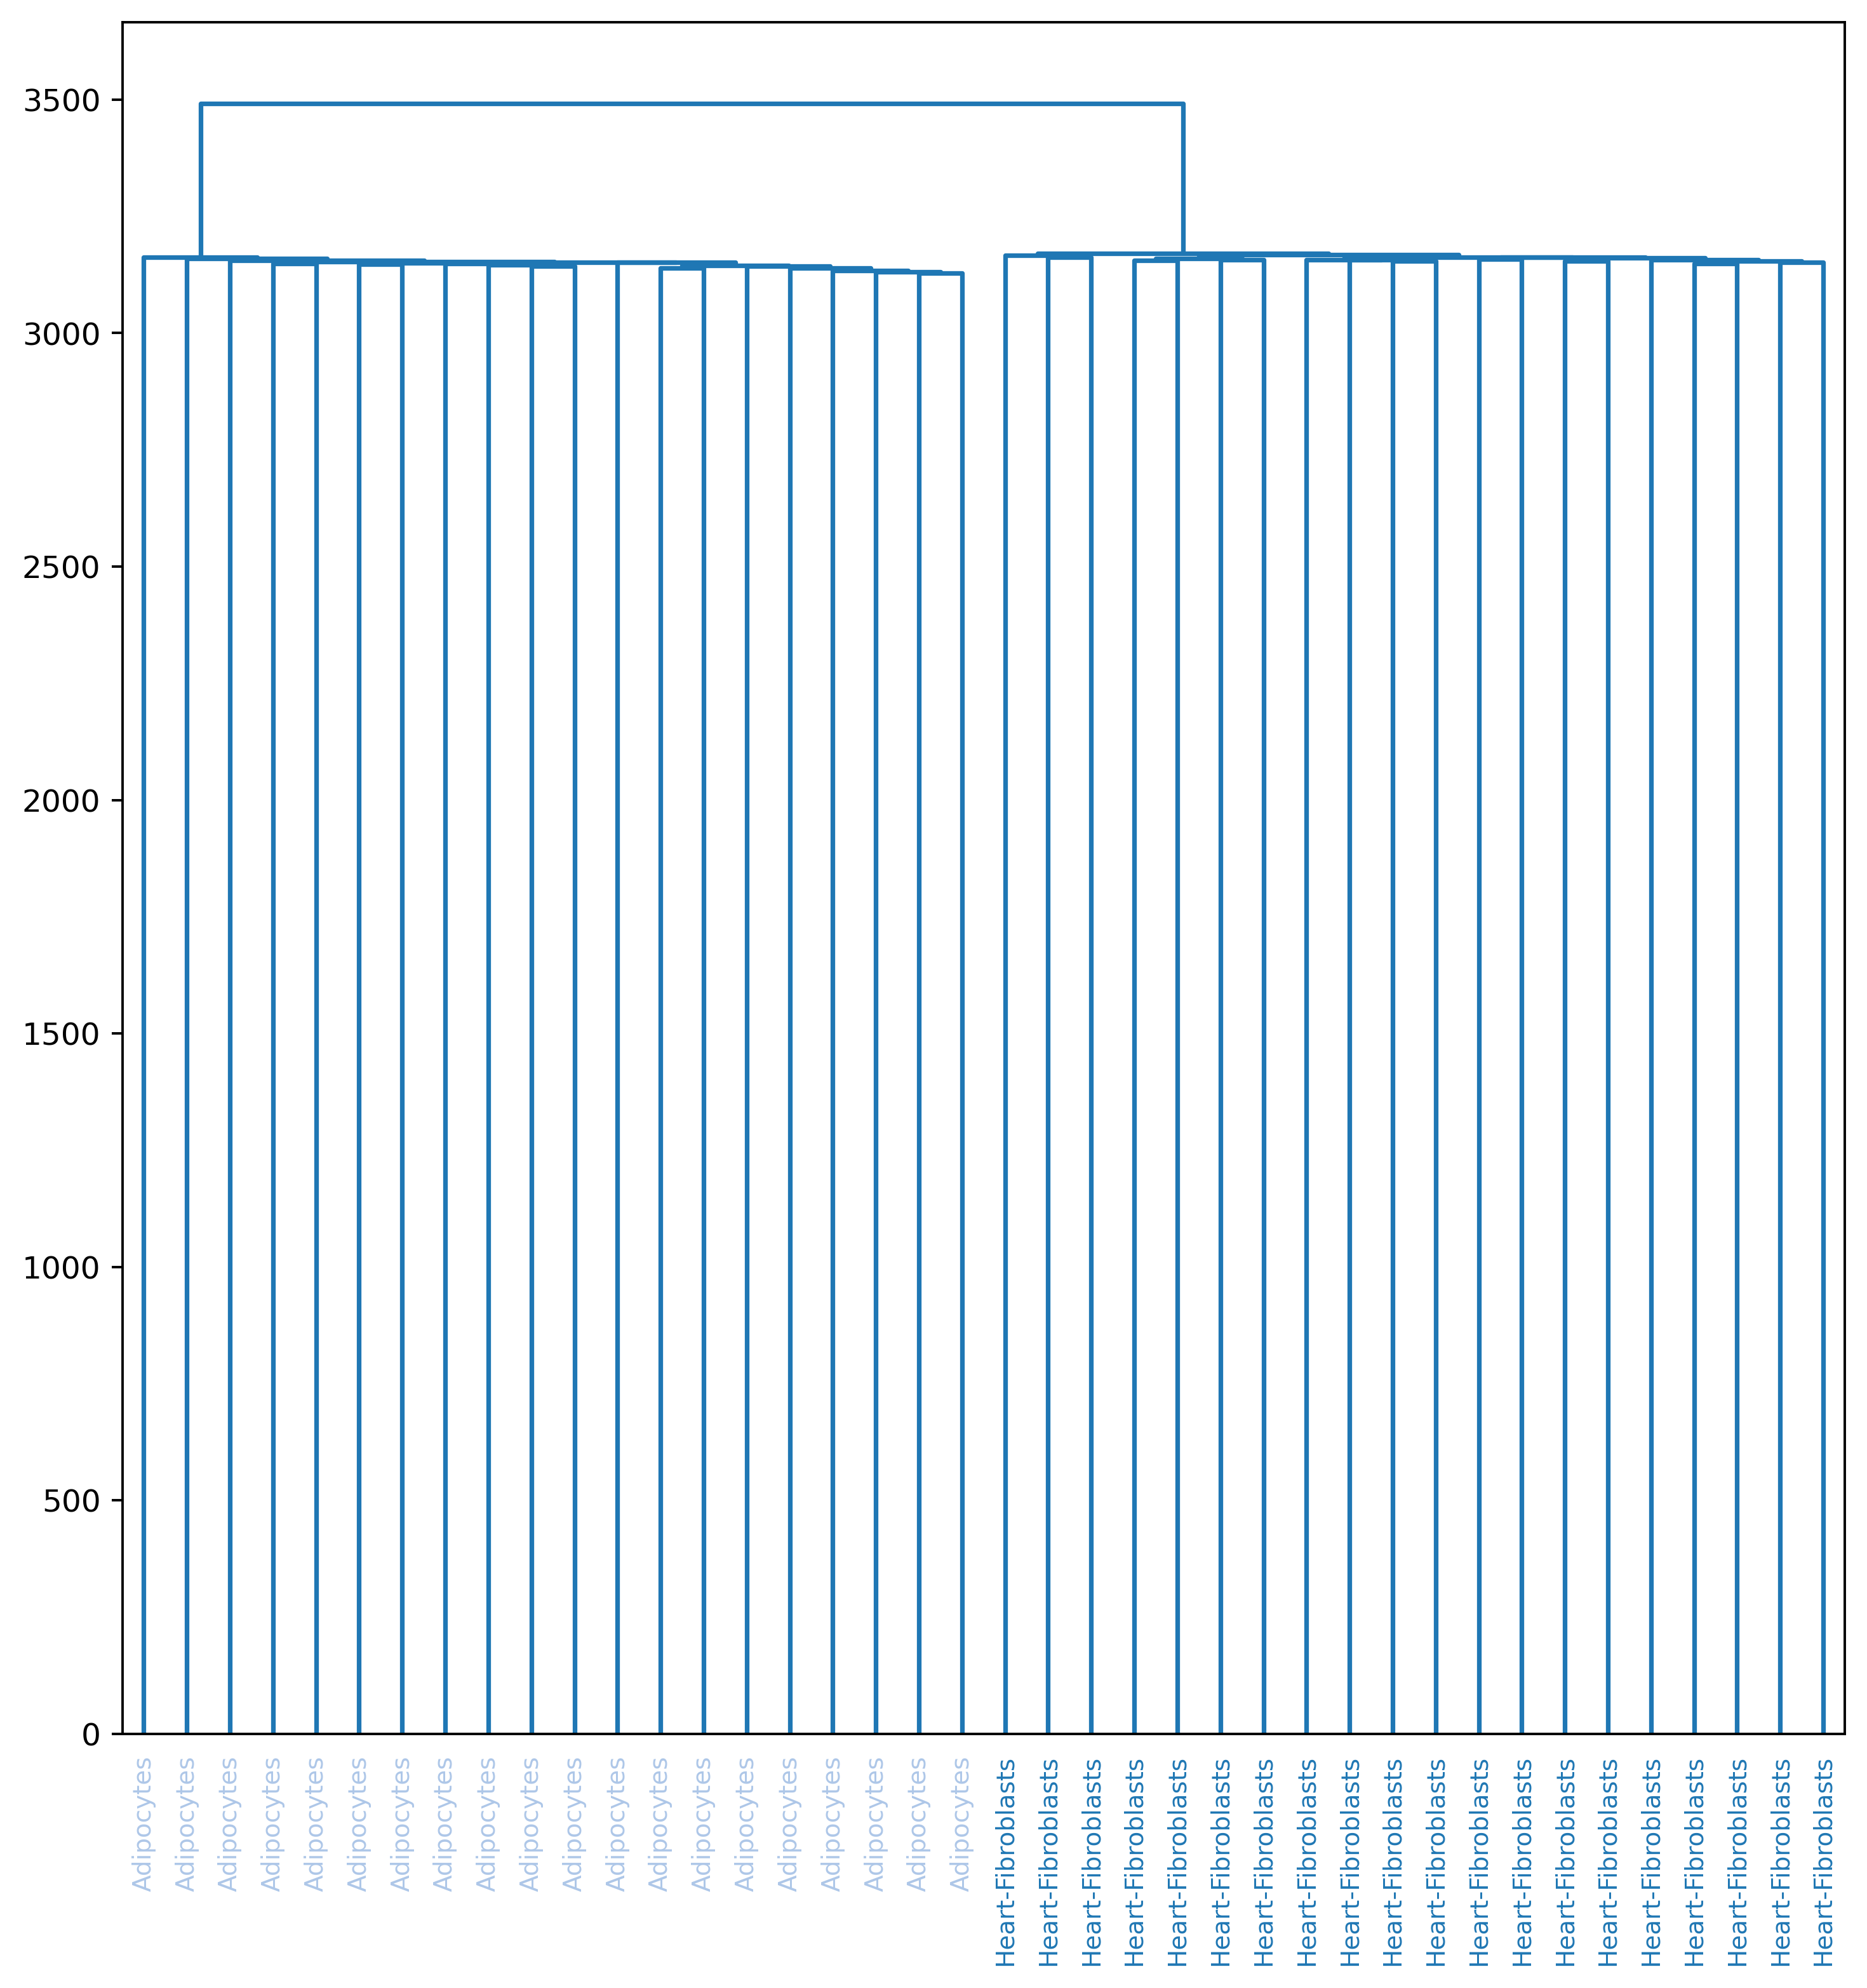

In [12]:
import re
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram


def shorten_label(label: str):
    m = re.search(r"GSM\d+_(.+?)-Z0+", label)
    return m.group(1)


with open(LABELS_PATH) as f:
    labels = f.read().split()

labels = list(map(shorten_label, labels))
labels_index = dict(zip(set(labels), range(len(labels))))


_, ax = plt.subplots(figsize=(10, 10), dpi=350)
dendrogram(
    linkage_data,
    color_threshold=2200,
    labels=labels,
    leaf_rotation=90,
)
for lbl in ax.get_xmajorticklabels():
    lbl.set_color(plt.cm.tab20.colors[labels_index[lbl.get_text()]])
plt.show()